# Notebook 6 — Model Evaluation & Comparison

| Trường | Nội dung |
|---|---|
| **Dự án** | Bayesian Uncertainty-Aware Financial Risk Forecasting |
| **Notebook** | 6 of 7 |
| **Input** | `models/baseline_predictions.csv` · `models/posterior_final.pkl` · `models/scaler.pkl` · `data/processed/sp500_features.csv` |
| **Output** | `results/comparison/comparison_metrics.json` · figures `reports/figures/nb6/` |
| **Trọng tâm** | **Head-to-head comparison trên cùng test set** · ROC/PR · Calibration · Uncertainty Analysis |

> **Fix so với phiên bản trước:** LR và BLR nay được đánh giá trên **cùng một test set** (2023 → 2024).  
> BLR chạy posterior predictive trực tiếp trên test set. Metric so sánh: **Accuracy, Precision, Recall, F2**.

## 1. Import & Cấu hình

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import os
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score,
    roc_auc_score, brier_score_loss,
    roc_curve, auc, precision_recall_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve

np.random.seed(42)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'legend.fontsize': 9
})

FIGURES_DIR   = '../reports/figures/nb6'
RESULTS_DIR   = '../results/comparison'
PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

COLOR_LR  = 'steelblue'
COLOR_BLR = 'tomato'
print('✓ Imports OK')

✓ Imports OK


## 2. Load dữ liệu & Tái tạo BLR predictions trên Test Set

**Lý do phải tái tạo:** NB4 chỉ lưu predictions trên *validation set* (2021–2023).  
Để so sánh fair, ta load `posterior_final.pkl` từ NB4, rồi chạy **Posterior Predictive (Monte Carlo)** trực tiếp trên *test set* (2023–2024).

$$\pi(x^*) = \frac{1}{M}\sum_{m=1}^{M}\sigma(x^{*\top}\theta^{(m)}), \quad \theta^{(m)} \sim \mathcal{N}(\mu_{\text{post}}, \Sigma_{\text{post}})$$

In [2]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

FEATURE_COLS = [
    'Return', 'Volatility', 'MA_Ratio', 'Lag1', 'Lag2',
    'Intraday_Range', 'Close_Position', 'Volume_Ratio',
    'Volatility_Ratio'
]
TARGET = 'Label'

# ✅ FIX: index_col=0 + parse_dates=True để giữ DatetimeIndex
df_feat = pd.read_csv(f'{PROCESSED_DIR}/sp500_features.csv',
                      index_col=0, parse_dates=True).sort_index()

n        = len(df_feat)
val_end  = int(n * 0.80)
test_df  = df_feat.iloc[val_end:]

scaler     = joblib.load(f'{MODELS_DIR}/scaler.pkl')
X_test     = scaler.transform(test_df[FEATURE_COLS].values)
y_test     = test_df[TARGET].values
test_dates = test_df.index   # DatetimeIndex

X_test_aug = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

print('=== Test Set (dùng chung cho LR và BLR) ===')
print(f'  Rows  : {len(test_df)}')
print(f'  Period: {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'  Class balance: {y_test.mean():.3f} positive ({y_test.sum()}/{len(y_test)})')

=== Test Set (dùng chung cho LR và BLR) ===
  Rows  : 478
  Period: 2023-02-03 → 2024-12-27
  Class balance: 0.172 positive (82/478)


In [3]:
baseline = pd.read_csv(f'{MODELS_DIR}/baseline_predictions.csv',
                       index_col=0, parse_dates=True)
baseline.index.name = 'Date'

y_true_lr = baseline['Actual'].values
y_prob_lr = baseline['Probability'].values
y_pred_lr = baseline['Prediction'].values

# Đọc threshold LR từ file json (nếu có) để tránh hardcode
try:
    with open(f'{RESULTS_DIR.replace("comparison","baseline")}/lr_metrics.json') as _f:
        _lr_json = json.load(_f)
        LR_THRESHOLD = float(_lr_json.get('threshold', 0.50))
except Exception:
    LR_THRESHOLD = round(float(np.unique(y_pred_lr)[0] if len(np.unique(y_prob_lr)) < 3 else 0.50), 2)

print('=== LR Predictions (từ NB3) ===')
print(f'  Shape  : {baseline.shape}')
print(f'  Period : {baseline.index.min().date()} → {baseline.index.max().date()}')
print(f'  Class balance: {y_true_lr.mean():.3f}')
print(f'  LR threshold  : τ={LR_THRESHOLD}')

=== LR Predictions (từ NB3) ===
  Shape  : (478, 3)
  Period : 2023-02-03 → 2024-12-27
  Class balance: 0.172
  LR threshold  : τ=0.4


In [4]:
with open(f'{MODELS_DIR}/posterior_final.pkl', 'rb') as f:
    posterior_state = pickle.load(f)

post_mean = posterior_state['mean']
post_cov  = posterior_state['cov']
M         = 2000

print(f'Posterior loaded: mean shape={post_mean.shape}, cov shape={post_cov.shape}')
print(f'Config: {posterior_state["config"]}')

np.random.seed(42)
theta_samples = np.random.multivariate_normal(mean=post_mean, cov=post_cov, size=M)

logits_test   = theta_samples @ X_test_aug.T
probs_test    = sigmoid(logits_test)

pred_mean_blr = probs_test.mean(axis=0)
pred_var_blr  = probs_test.var(axis=0)
ci_lower_blr  = np.percentile(probs_test, 2.5,  axis=0)
ci_upper_blr  = np.percentile(probs_test, 97.5, axis=0)
ci_width_blr  = ci_upper_blr - ci_lower_blr

try:
    with open('../results/bayesian/bayesian_threshold.json') as f:
        thr_json      = json.load(f)
        BLR_THRESHOLD = float(thr_json.get('best_threshold', 0.17))
    print(f'✓ Loaded BLR threshold từ NB5: τ={BLR_THRESHOLD}')
except FileNotFoundError:
    BLR_THRESHOLD = 0.17
    print(f'⚠ bayesian_threshold.json không tìm thấy — dùng τ={BLR_THRESHOLD}')

y_pred_blr = (pred_mean_blr >= BLR_THRESHOLD).astype(int)
y_true_blr = y_test
y_prob_blr = pred_mean_blr

assert np.array_equal(y_true_lr, y_true_blr), 'y_true không khớp — kiểm tra lại split!'

print()
print('=== BLR Posterior Predictive trên Test Set ===')
print(f'  M (MC samples)    : {M}')
print(f'  BLR threshold τ   : {BLR_THRESHOLD}')
print(f'  Pred Mean range   : [{pred_mean_blr.min():.4f}, {pred_mean_blr.max():.4f}]')
print(f'  Pred Var range    : [{pred_var_blr.min():.6f}, {pred_var_blr.max():.6f}]')
print(f'  CI Width mean     : {ci_width_blr.mean():.4f}')
print(f'  ✓ Ground truth đồng nhất: LR và BLR cùng test set')

Posterior loaded: mean shape=(10,), cov shape=(10, 10)
Config: {'batch_size': 20, 'discount': 0.95, 'map_lr': 0.01, 'map_n_iter': 300, 'prior_variance': 1.0, 'mc_samples': 1000}
✓ Loaded BLR threshold từ NB5: τ=0.17

=== BLR Posterior Predictive trên Test Set ===
  M (MC samples)    : 2000
  BLR threshold τ   : 0.17
  Pred Mean range   : [0.0427, 0.5805]
  Pred Var range    : [0.000307, 0.033627]
  CI Width mean     : 0.1862
  ✓ Ground truth đồng nhất: LR và BLR cùng test set


## 3. Confidence Score cho BLR

Tính lại Confidence Score theo công thức **nhất quán với NB5** (robust quantile normalization):

$$U_i = \text{CI\_Width}_i \quad \text{(uncertainty thô)}$$

$$\hat{U}_i = \text{clip}\!\left(\frac{U_i - U_{2.5\%}}{U_{97.5\%} - U_{2.5\%}},\; 0,\; 1\right) \in [0,1]$$

$$C_i = 1 - \hat{U}_i \in [0,1]$$

Lý do dùng robust quantile thay vì max-normalization: loại bỏ ảnh hưởng của outlier CI Width, phân phối Confidence ổn định hơn.

In [5]:
# ✅ FIX: Robust quantile normalization — nhất quán với NB5
U      = ci_width_blr
U_low  = np.percentile(U, 2.5)
U_high = np.percentile(U, 97.5)
U_norm = np.clip((U - U_low) / (U_high - U_low + 1e-10), 0, 1)
confidence_blr = np.clip(1 - U_norm, 0, 1)

# Confidence Bucket (tertile, data-driven — đồng bộ NB5)
thr_high = np.percentile(confidence_blr, 67)
thr_med  = np.percentile(confidence_blr, 33)

def assign_bucket(c):
    if c >= thr_high:  return 'High'
    elif c >= thr_med: return 'Medium'
    else:              return 'Low'

conf_bucket = np.array([assign_bucket(c) for c in confidence_blr])

print('=== Confidence Score (Test Set) ===')
print(f'  Normalization: robust quantile [p2.5={U_low:.4f}, p97.5={U_high:.4f}]')
print(f'  Range   : [{confidence_blr.min():.4f}, {confidence_blr.max():.4f}]')
print(f'  Mean    : {confidence_blr.mean():.4f}')
print(f'  Thresholds — High: ≥{thr_high:.4f}  Medium: [{thr_med:.4f}, {thr_high:.4f})')
print()
unique, counts = np.unique(conf_bucket, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {u:8s}: {c} ({c/len(conf_bucket)*100:.1f}%)')

=== Confidence Score (Test Set) ===
  Normalization: robust quantile [p2.5=0.0912, p97.5=0.4728]
  Range   : [0.0000, 1.0000]
  Mean    : 0.7547
  Thresholds — High: ≥0.9104  Medium: [0.7345, 0.9104)

  High    : 158 (33.1%)
  Low     : 158 (33.1%)
  Medium  : 162 (33.9%)


## 4. Section 6.1 — Overall Performance Comparison (Head-to-Head, same test set)

In [6]:
def compute_metrics(y_true, y_pred, y_prob, model_name):
    """Tính Accuracy, Precision, Recall, F2 (β=2) và các metric bổ sung."""
    p_curve, r_curve, _ = precision_recall_curve(y_true, y_prob)
    return {
        'Model'      : model_name,
        'Accuracy'   : accuracy_score(y_true, y_pred),
        'Precision'  : precision_score(y_true, y_pred, zero_division=0),
        'Recall'     : recall_score(y_true, y_pred, zero_division=0),
        'F2-Score'   : fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'F1-Score'   : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'    : roc_auc_score(y_true, y_prob),
        'AUPRC'      : auc(r_curve, p_curve),
        'Brier Score': brier_score_loss(y_true, y_prob)
    }

metrics_lr  = compute_metrics(y_true_lr,  y_pred_lr,  y_prob_lr,  'Logistic Regression')
metrics_blr = compute_metrics(y_true_blr, y_pred_blr, y_prob_blr, 'Bayesian LR')

metrics_df = pd.DataFrame([metrics_lr, metrics_blr]).set_index('Model')

print('=' * 70)
print('   OVERALL PERFORMANCE COMPARISON  (same test set 2023 → 2024)')
print('=' * 70)
print(metrics_df.round(4).to_string())
print()
print('Note: Brier Score thấp hơn = tốt hơn  |  Các metric khác: cao hơn = tốt hơn')
print(f'      LR threshold  : τ={LR_THRESHOLD} — optimized on val (NB3, metric=F2)')
print(f'      BLR threshold : τ={BLR_THRESHOLD} — optimized on val (NB5, metric=F2)')

# Delta — focus vào 4 metric chính
print('\n=== Delta (BLR − LR) — 4 metric chính ===')
for metric in ['Accuracy', 'Precision', 'Recall', 'F2-Score']:
    diff  = metrics_blr[metric] - metrics_lr[metric]
    arrow = '✓ BLR better' if diff > 0 else '✗ BLR worse'
    print(f'  {metric:<14}: LR={metrics_lr[metric]:.4f}  BLR={metrics_blr[metric]:.4f}  Δ={diff:+.4f}  {arrow}')
print()
for metric in ['ROC-AUC', 'AUPRC', 'Brier Score']:
    diff  = metrics_blr[metric] - metrics_lr[metric]
    if metric == 'Brier Score':
        arrow = '✓ BLR better' if diff < 0 else '✗ BLR worse'
    else:
        arrow = '✓ BLR better' if diff > 0 else '✗ BLR worse'
    print(f'  {metric:<14}: LR={metrics_lr[metric]:.4f}  BLR={metrics_blr[metric]:.4f}  Δ={diff:+.4f}  {arrow}')

   OVERALL PERFORMANCE COMPARISON  (same test set 2023 → 2024)
                     Accuracy  Precision  Recall  F2-Score  F1-Score  ROC-AUC   AUPRC  Brier Score
Model                                                                                             
Logistic Regression    0.6297     0.2791  0.7317    0.5525    0.4040    0.687  0.2886       0.1982
Bayesian LR            0.6904     0.3012  0.6098    0.5061    0.4032    0.675  0.2690       0.1361

Note: Brier Score thấp hơn = tốt hơn  |  Các metric khác: cao hơn = tốt hơn
      LR threshold  : τ=0.4 — optimized on val (NB3, metric=F2)
      BLR threshold : τ=0.17 — optimized on val (NB5, metric=F2)

=== Delta (BLR − LR) — 4 metric chính ===
  Accuracy      : LR=0.6297  BLR=0.6904  Δ=+0.0607  ✓ BLR better
  Precision     : LR=0.2791  BLR=0.3012  Δ=+0.0221  ✓ BLR better
  Recall        : LR=0.7317  BLR=0.6098  Δ=-0.1220  ✗ BLR worse
  F2-Score      : LR=0.5525  BLR=0.5061  Δ=-0.0464  ✗ BLR worse

  ROC-AUC       : LR=0.6870  BLR=

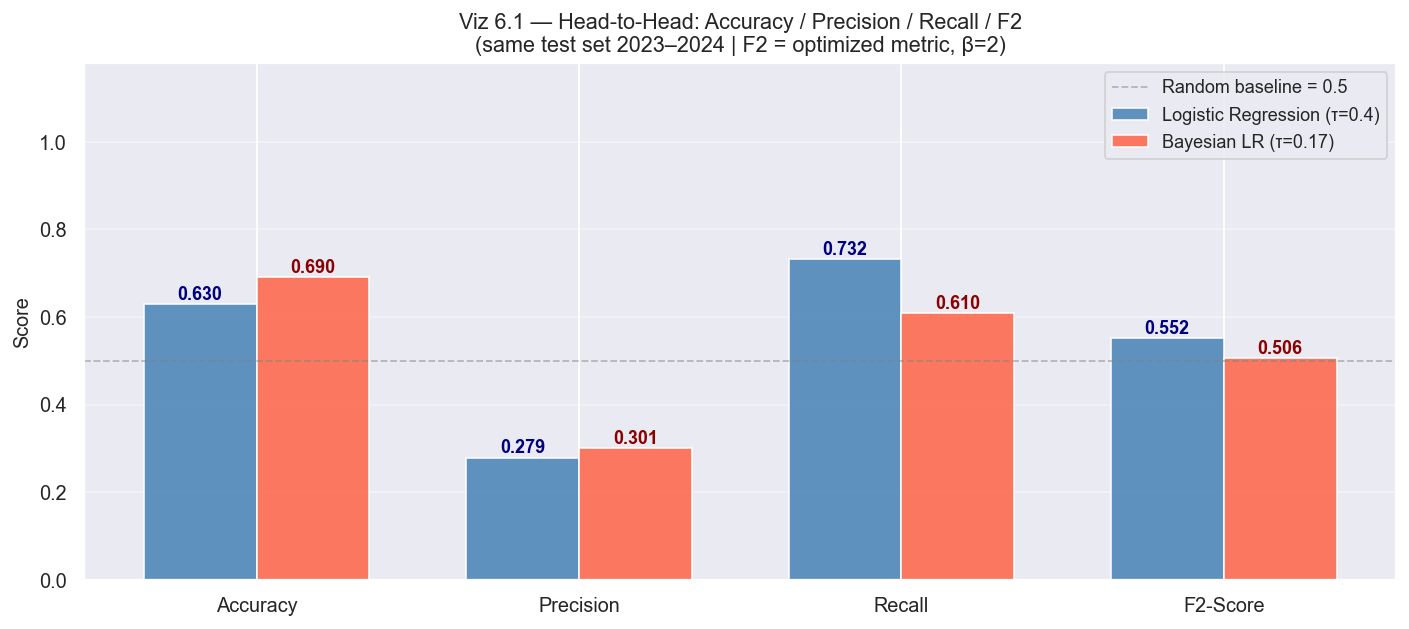

Saved → ../reports/figures/nb6/viz61_performance_comparison.png


In [7]:
# ── Viz 6.1: Bar chart head-to-head — 4 metric chính ───────────────────────
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F2-Score']
lr_vals  = [metrics_lr[m]  for m in metric_labels]
blr_vals = [metrics_blr[m] for m in metric_labels]

x     = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_lr  = ax.bar(x - width/2, lr_vals,  width, label=f'Logistic Regression (τ={LR_THRESHOLD})',
                  color=COLOR_LR,  alpha=0.85, edgecolor='white')
bars_blr = ax.bar(x + width/2, blr_vals, width, label=f'Bayesian LR (τ={BLR_THRESHOLD})',
                  color=COLOR_BLR, alpha=0.85, edgecolor='white')

for bar in bars_lr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.010,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, color='navy', fontweight='bold')
for bar in bars_blr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.010,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, color='darkred', fontweight='bold')

ax.set_title('Viz 6.1 — Head-to-Head: Accuracy / Precision / Recall / F2\n'
             '(same test set 2023–2024 | F2 = optimized metric, β=2)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.18)
ax.axhline(0.5, color='gray', lw=1, ls='--', alpha=0.5, label='Random baseline = 0.5')
ax.legend(fontsize=10)
ax.grid(alpha=0.4, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz61_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz61_performance_comparison.png')

## 5. Section 6.2 — Confusion Matrix So Sánh

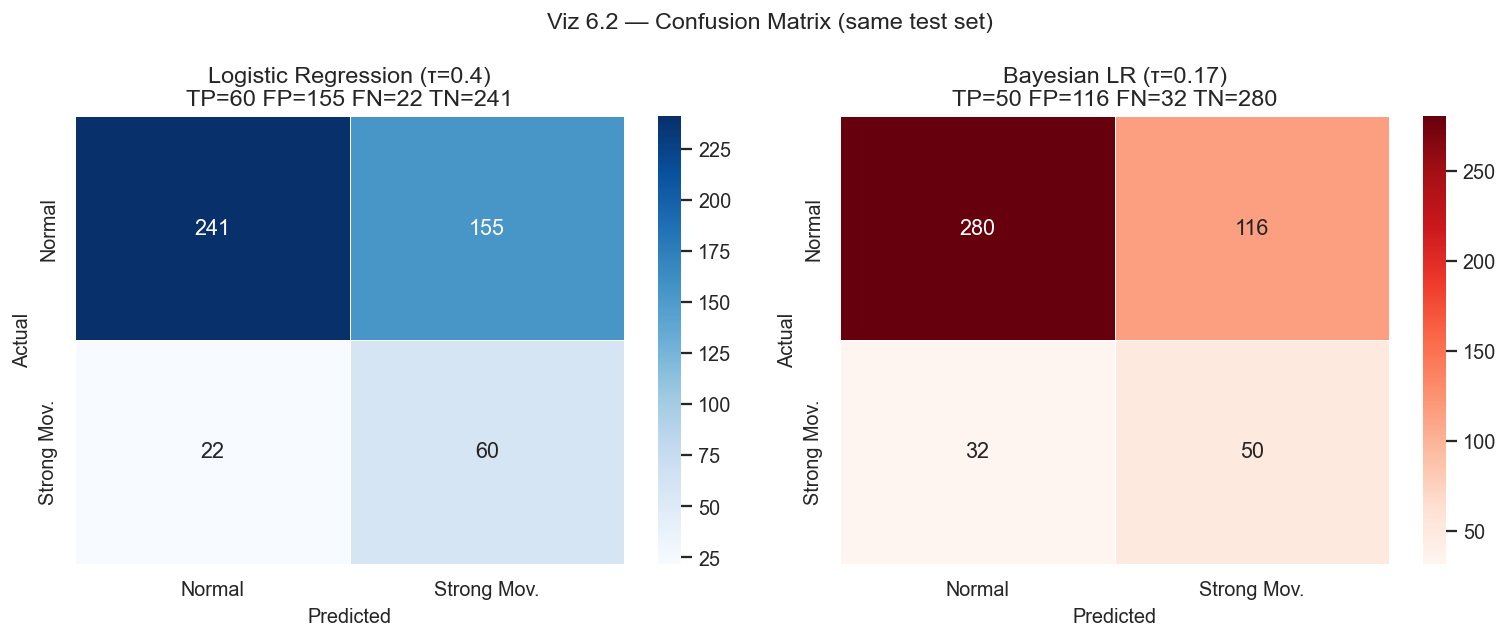

Saved → ../reports/figures/nb6/viz62_confusion_matrix.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Viz 6.2 — Confusion Matrix (same test set)', fontsize=13)

label_names = ['Normal', 'Strong Mov.']

for ax, y_pred, title, color in [
    (axes[0], y_pred_lr,  f'Logistic Regression (τ={LR_THRESHOLD})', 'Blues'),
    (axes[1], y_pred_blr, f'Bayesian LR (τ={BLR_THRESHOLD})',         'Reds')
]:
    cm = confusion_matrix(y_true_lr, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=label_names, yticklabels=label_names,
                ax=ax, linewidths=0.5)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{title}\nTP={tp} FP={fp} FN={fn} TN={tn}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz62_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz62_confusion_matrix.png')

## 6. Section 6.3 — ROC & Precision-Recall Curves

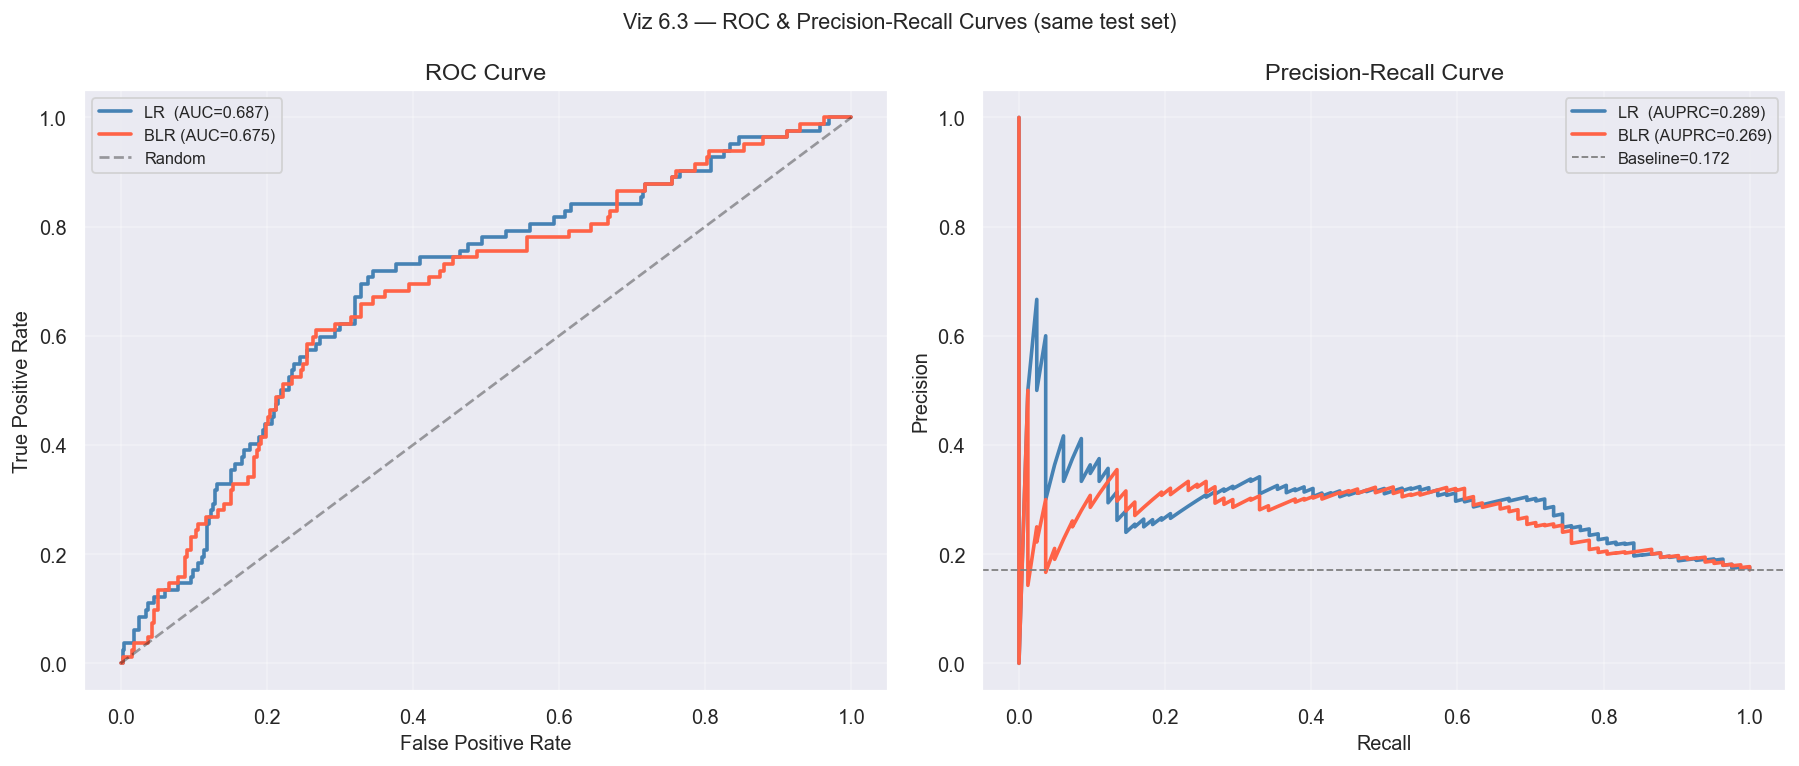

Saved → ../reports/figures/nb6/viz63_roc_pr_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Viz 6.3 — ROC & Precision-Recall Curves (same test set)', fontsize=12)

for y_t, y_p, label, color in [
    (y_true_lr,  y_prob_lr,  f'LR  (AUC={metrics_lr["ROC-AUC"]:.3f})',  COLOR_LR),
    (y_true_blr, y_prob_blr, f'BLR (AUC={metrics_blr["ROC-AUC"]:.3f})', COLOR_BLR)
]:
    fpr, tpr, _ = roc_curve(y_t, y_p)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=label)

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

for y_t, y_p, label, color in [
    (y_true_lr,  y_prob_lr,  f'LR  (AUPRC={metrics_lr["AUPRC"]:.3f})',  COLOR_LR),
    (y_true_blr, y_prob_blr, f'BLR (AUPRC={metrics_blr["AUPRC"]:.3f})', COLOR_BLR)
]:
    pc, rc, _ = precision_recall_curve(y_t, y_p)
    axes[1].plot(rc, pc, color=color, lw=2, label=label)

baseline_rate = y_true_lr.mean()
axes[1].axhline(baseline_rate, color='gray', lw=1, ls='--',
                label=f'Baseline={baseline_rate:.3f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz63_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz63_roc_pr_curves.png')

## 7. Section 6.4 — Calibration Analysis

**Brier Score** $= \frac{1}{N}\sum_i(\pi(x_i) - y_i)^2$ — thấp hơn = tốt hơn.  
**Reliability Diagram:** Predicted probability vs Fraction of positives. Gần đường chéo y=x → well-calibrated.

=== Calibration Analysis ===
Brier Score — LR  : 0.1982
Brier Score — BLR : 0.1361
Difference        : -0.0621 (BLR better ✓)


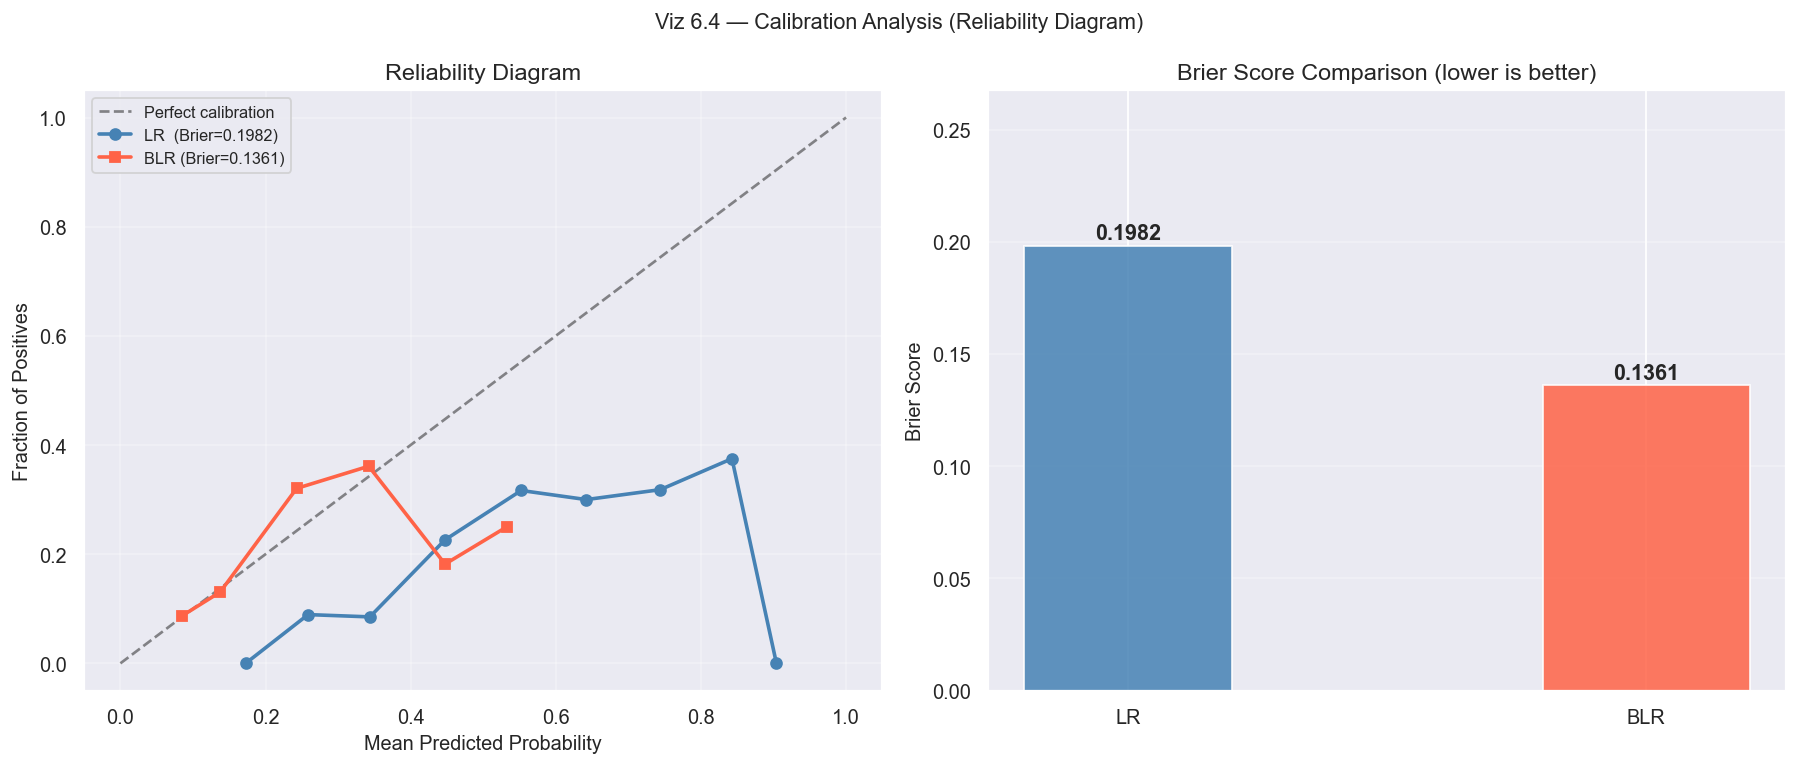

Saved → ../reports/figures/nb6/viz64_calibration.png


In [10]:
brier_lr  = metrics_lr['Brier Score']
brier_blr = metrics_blr['Brier Score']

print('=== Calibration Analysis ===')
print(f'Brier Score — LR  : {brier_lr:.4f}')
print(f'Brier Score — BLR : {brier_blr:.4f}')
print(f'Difference        : {brier_blr - brier_lr:+.4f} ({"BLR better ✓" if brier_blr < brier_lr else "LR better"})')

frac_pos_lr,  mean_pred_lr  = calibration_curve(y_true_lr,  y_prob_lr,  n_bins=10)
frac_pos_blr, mean_pred_blr = calibration_curve(y_true_blr, y_prob_blr, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Viz 6.4 — Calibration Analysis (Reliability Diagram)', fontsize=12)

axes[0].plot([0,1],[0,1], 'k--', alpha=0.5, label='Perfect calibration')
axes[0].plot(mean_pred_lr,  frac_pos_lr,  'o-', color=COLOR_LR,  lw=2,
             label=f'LR  (Brier={brier_lr:.4f})')
axes[0].plot(mean_pred_blr, frac_pos_blr, 's-', color=COLOR_BLR, lw=2,
             label=f'BLR (Brier={brier_blr:.4f})')
axes[0].set_title('Reliability Diagram')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(['LR', 'BLR'], [brier_lr, brier_blr],
            color=[COLOR_LR, COLOR_BLR], alpha=0.85, edgecolor='white', width=0.4)
axes[1].text(0, brier_lr  + 0.003, f'{brier_lr:.4f}',  ha='center', fontsize=12, fontweight='bold')
axes[1].text(1, brier_blr + 0.003, f'{brier_blr:.4f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Brier Score Comparison (lower is better)')
axes[1].set_ylabel('Brier Score')
axes[1].set_ylim(0, max(brier_lr, brier_blr) * 1.35)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz64_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz64_calibration.png')

## 8. Section 6.5 — Uncertainty Analysis (BLR Only)

Đây là phần **đặc trưng Bayesian** mà LR không có. Ta phân tích:
- Predictive Variance phân bố theo Actual Label
- CI Width theo thời gian
- Confidence Score vs Accuracy (calibration uncertainty)

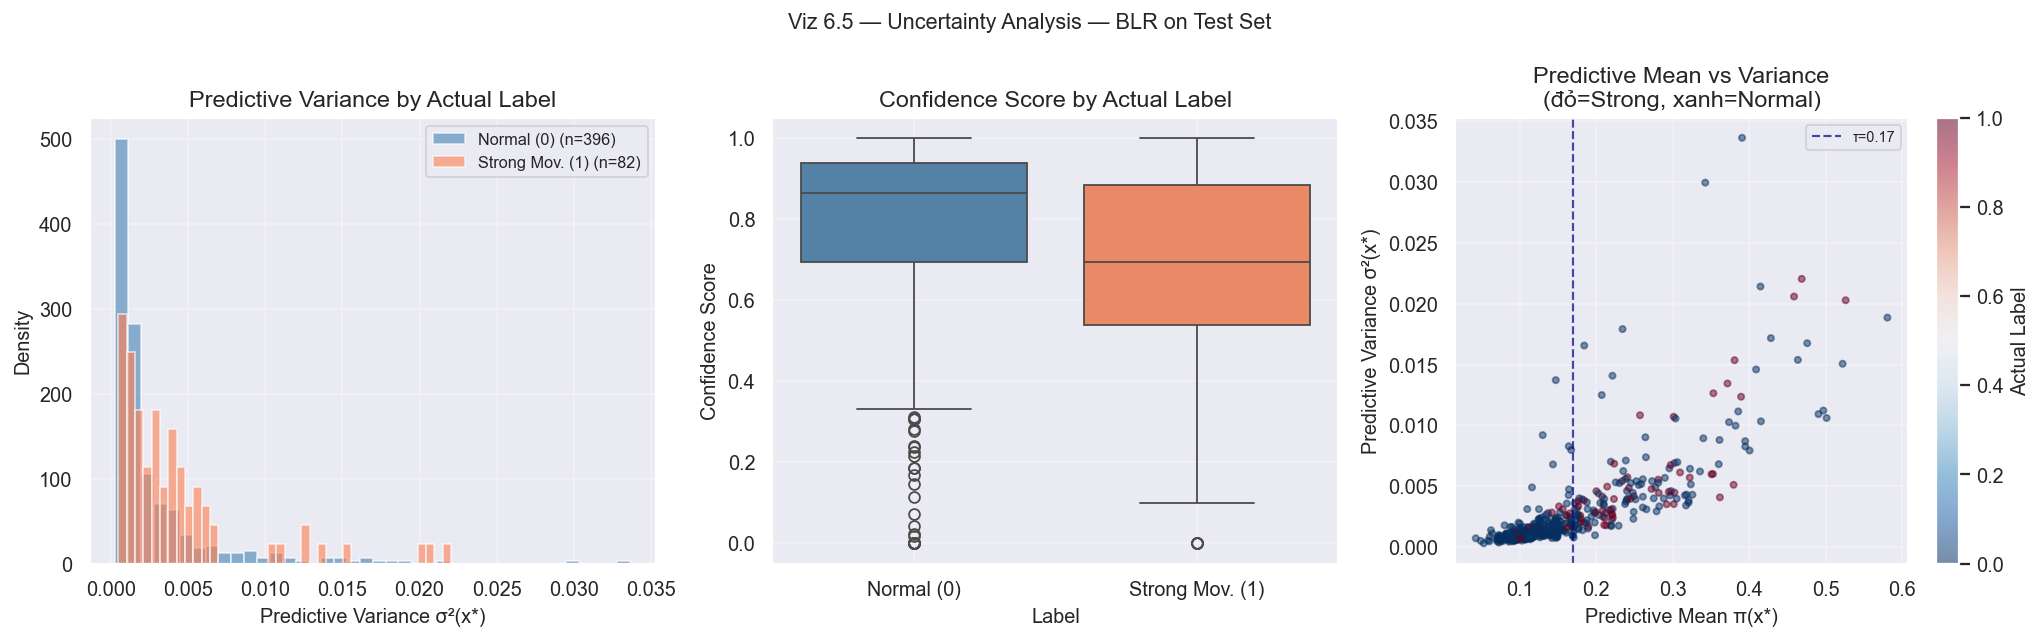

Saved → ../reports/figures/nb6/viz65_uncertainty_analysis.png

=== Predictive Variance by Label ===
  Normal         : mean=0.002776  median=0.001386  std=0.003834
  Strong Mov.    : mean=0.004204  median=0.002856  std=0.004478


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Viz 6.5 — Uncertainty Analysis — BLR on Test Set', fontsize=12)

for label, color, name in [(0,'steelblue','Normal (0)'), (1,'coral','Strong Mov. (1)')]:
    mask = y_true_blr == label
    axes[0].hist(pred_var_blr[mask], bins=40, alpha=0.6,
                 color=color, label=f'{name} (n={mask.sum()})', density=True)
axes[0].set_title('Predictive Variance by Actual Label')
axes[0].set_xlabel('Predictive Variance σ²(x*)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

df_conf = pd.DataFrame({'Confidence': confidence_blr, 'Label': y_true_blr})
sns.boxplot(data=df_conf, x='Label', y='Confidence',
            hue='Label', palette={0: 'steelblue', 1: 'coral'},
            legend=False, ax=axes[1])
axes[1].set_title('Confidence Score by Actual Label')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Normal (0)', 'Strong Mov. (1)'])
axes[1].set_ylabel('Confidence Score')
axes[1].grid(alpha=0.3)

sc = axes[2].scatter(pred_mean_blr, pred_var_blr,
                     c=y_true_blr, cmap='RdBu_r', alpha=0.5, s=12)
axes[2].axvline(BLR_THRESHOLD, color='navy', lw=1.2, ls='--',
                alpha=0.7, label=f'τ={BLR_THRESHOLD}')
axes[2].set_title('Predictive Mean vs Variance\n(đỏ=Strong, xanh=Normal)')
axes[2].set_xlabel('Predictive Mean π(x*)')
axes[2].set_ylabel('Predictive Variance σ²(x*)')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)
plt.colorbar(sc, ax=axes[2], label='Actual Label')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz65_uncertainty_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz65_uncertainty_analysis.png')

print()
print('=== Predictive Variance by Label ===')
for label, name in [(0, 'Normal'), (1, 'Strong Mov.')]:
    mask = y_true_blr == label
    v = pred_var_blr[mask]
    print(f'  {name:15s}: mean={v.mean():.6f}  median={np.median(v):.6f}  std={v.std():.6f}')

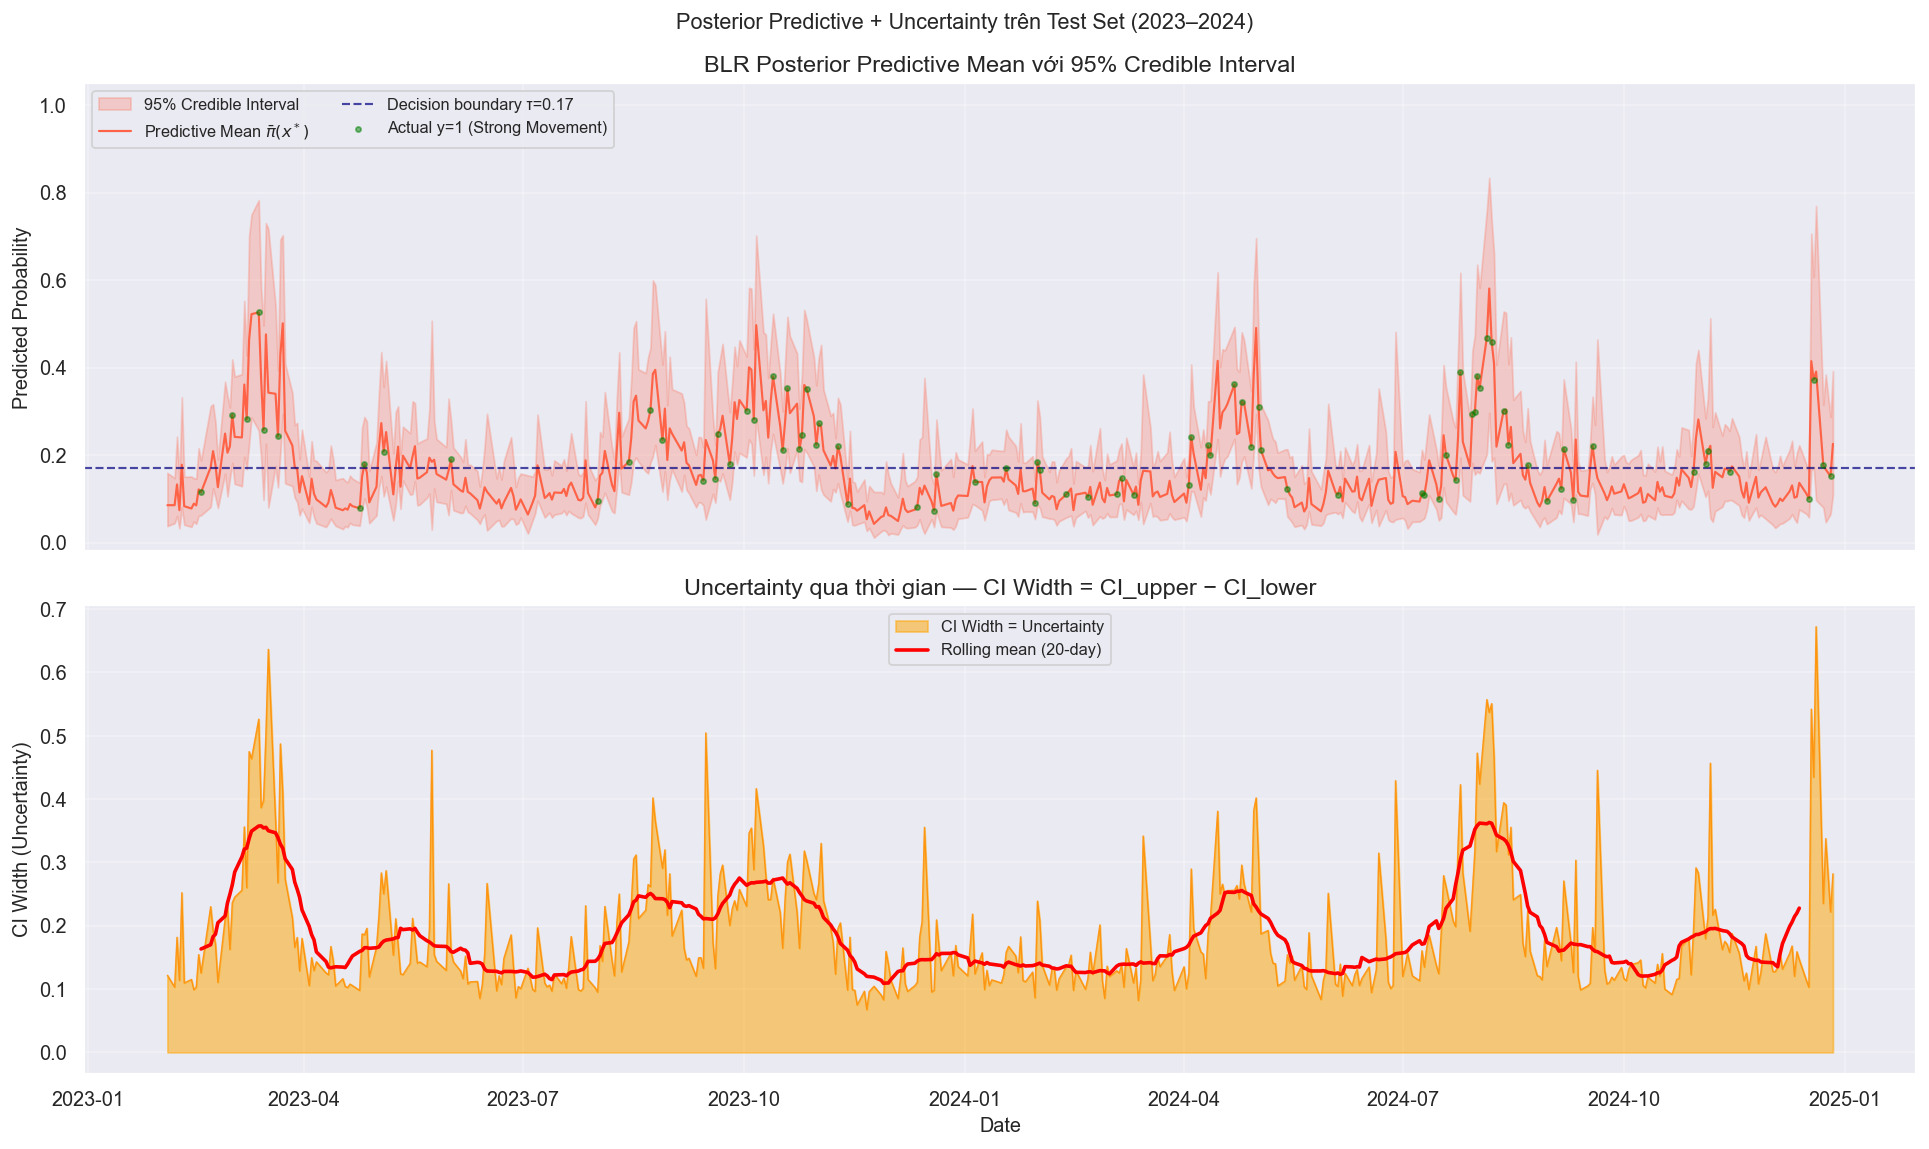

Saved → ../reports/figures/nb6/viz65b_uncertainty_timeseries.png


In [12]:
dates_plot = pd.to_datetime(test_dates)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle('Posterior Predictive + Uncertainty trên Test Set (2023–2024)', fontsize=12)

axes[0].fill_between(dates_plot, ci_lower_blr, ci_upper_blr,
                     alpha=0.25, color='tomato', label='95% Credible Interval')
axes[0].plot(dates_plot, pred_mean_blr, color='tomato', lw=1.2,
             label=r'Predictive Mean $\bar{\pi}(x^*)$')
axes[0].axhline(BLR_THRESHOLD, color='navy', lw=1.2, ls='--', alpha=0.7,
                label=f'Decision boundary τ={BLR_THRESHOLD}')
pos_mask = y_true_blr == 1
axes[0].scatter(dates_plot[pos_mask], pred_mean_blr[pos_mask],
                color='green', s=8, alpha=0.5, zorder=3,
                label='Actual y=1 (Strong Movement)')
axes[0].set_ylabel('Predicted Probability')
axes[0].set_ylim(-0.02, 1.05)
axes[0].set_title('BLR Posterior Predictive Mean với 95% Credible Interval')
axes[0].legend(loc='upper left', fontsize=9, ncol=2)
axes[0].grid(alpha=0.3)

axes[1].fill_between(dates_plot, 0, ci_width_blr, alpha=0.5,
                     color='orange', label='CI Width = Uncertainty')
axes[1].plot(dates_plot, ci_width_blr, color='darkorange', lw=0.8, alpha=0.8)
ci_series   = pd.Series(ci_width_blr, index=dates_plot)
rolling_unc = ci_series.rolling(window=20, center=True).mean()
axes[1].plot(rolling_unc.index, rolling_unc.values, color='red', lw=2,
             label='Rolling mean (20-day)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('CI Width (Uncertainty)')
axes[1].set_title('Uncertainty qua thời gian — CI Width = CI_upper − CI_lower')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz65b_uncertainty_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz65b_uncertainty_timeseries.png')

## 9. Section 6.6 — Performance by Confidence Bucket

Kiểm định giả thuyết chính: **prediction có confidence cao thì chính xác hơn**.

Với metric chính là F2 ($\beta=2$), kỳ vọng monotonicity trên **Accuracy** (không phải F2):

$$\text{Accuracy}_{High} > \text{Accuracy}_{Medium} > \text{Accuracy}_{Low}$$

**Lưu ý về F2 và bucket:** F2 không nhất thiết monotone theo bucket vì High-bucket thường có Recall thấp (điểm confident → pred_mean xa threshold → đa số là Normal được predict đúng), F2 penalize recall thấp nặng nên F2(High) có thể thấp hơn F2(Low). Đây là hành vi bình thường — Accuracy mới là metric để kiểm tra monotonicity.

In [13]:
bucket_stats = {}
for bucket in ['High', 'Medium', 'Low']:
    mask     = conf_bucket == bucket
    n_bucket = mask.sum()
    if n_bucket == 0:
        continue
    yt = y_true_blr[mask]
    yp = y_pred_blr[mask]
    bucket_stats[bucket] = {
        'N'              : n_bucket,
        'Mean Confidence': confidence_blr[mask].mean(),
        'Mean Variance'  : pred_var_blr[mask].mean(),
        'Accuracy'       : accuracy_score(yt, yp),
        'Precision'      : precision_score(yt, yp, zero_division=0),
        'Recall'         : recall_score(yt, yp, zero_division=0),
        'F2'             : fbeta_score(yt, yp, beta=2, zero_division=0),
        'F1'             : f1_score(yt, yp, zero_division=0),
    }

bucket_df = pd.DataFrame(bucket_stats).T.loc[['High', 'Medium', 'Low']]

print('=== Performance by Confidence Bucket (BLR on Test Set) ===')
print(bucket_df.round(4).to_string())
print()

acc_high = bucket_stats.get('High',   {}).get('Accuracy', np.nan)
acc_med  = bucket_stats.get('Medium', {}).get('Accuracy', np.nan)
acc_low  = bucket_stats.get('Low',    {}).get('Accuracy', np.nan)
f2_high  = bucket_stats.get('High',   {}).get('F2', np.nan)
f2_med   = bucket_stats.get('Medium', {}).get('F2', np.nan)
f2_low   = bucket_stats.get('Low',    {}).get('F2', np.nan)

mono_acc = acc_high > acc_med > acc_low
print(f'Monotonicity — Accuracy: {acc_high:.3f} > {acc_med:.3f} > {acc_low:.3f}  → {"✓ ĐÚNG" if mono_acc else "⚠ Không hoàn toàn"}')
print(f'Monotonicity — F2      : {f2_high:.3f} > {f2_med:.3f} > {f2_low:.3f}  → {"✓ ĐÚNG" if f2_high>f2_med>f2_low else "⚠ Không hoàn toàn (bình thường — xem giải thích Section 9)"}')

=== Performance by Confidence Bucket (BLR on Test Set) ===
            N  Mean Confidence  Mean Variance  Accuracy  Precision  Recall      F2      F1
High    158.0           0.9545         0.0008    0.8987     0.0000  0.0000  0.0000  0.0000
Medium  162.0           0.8365         0.0016    0.8025     0.2963  0.3810  0.3604  0.3333
Low     158.0           0.4711         0.0067    0.3671     0.3066  0.8936  0.6462  0.4565

Monotonicity — Accuracy: 0.899 > 0.802 > 0.367  → ✓ ĐÚNG
Monotonicity — F2      : 0.000 > 0.360 > 0.646  → ⚠ Không hoàn toàn (bình thường — xem giải thích Section 9)


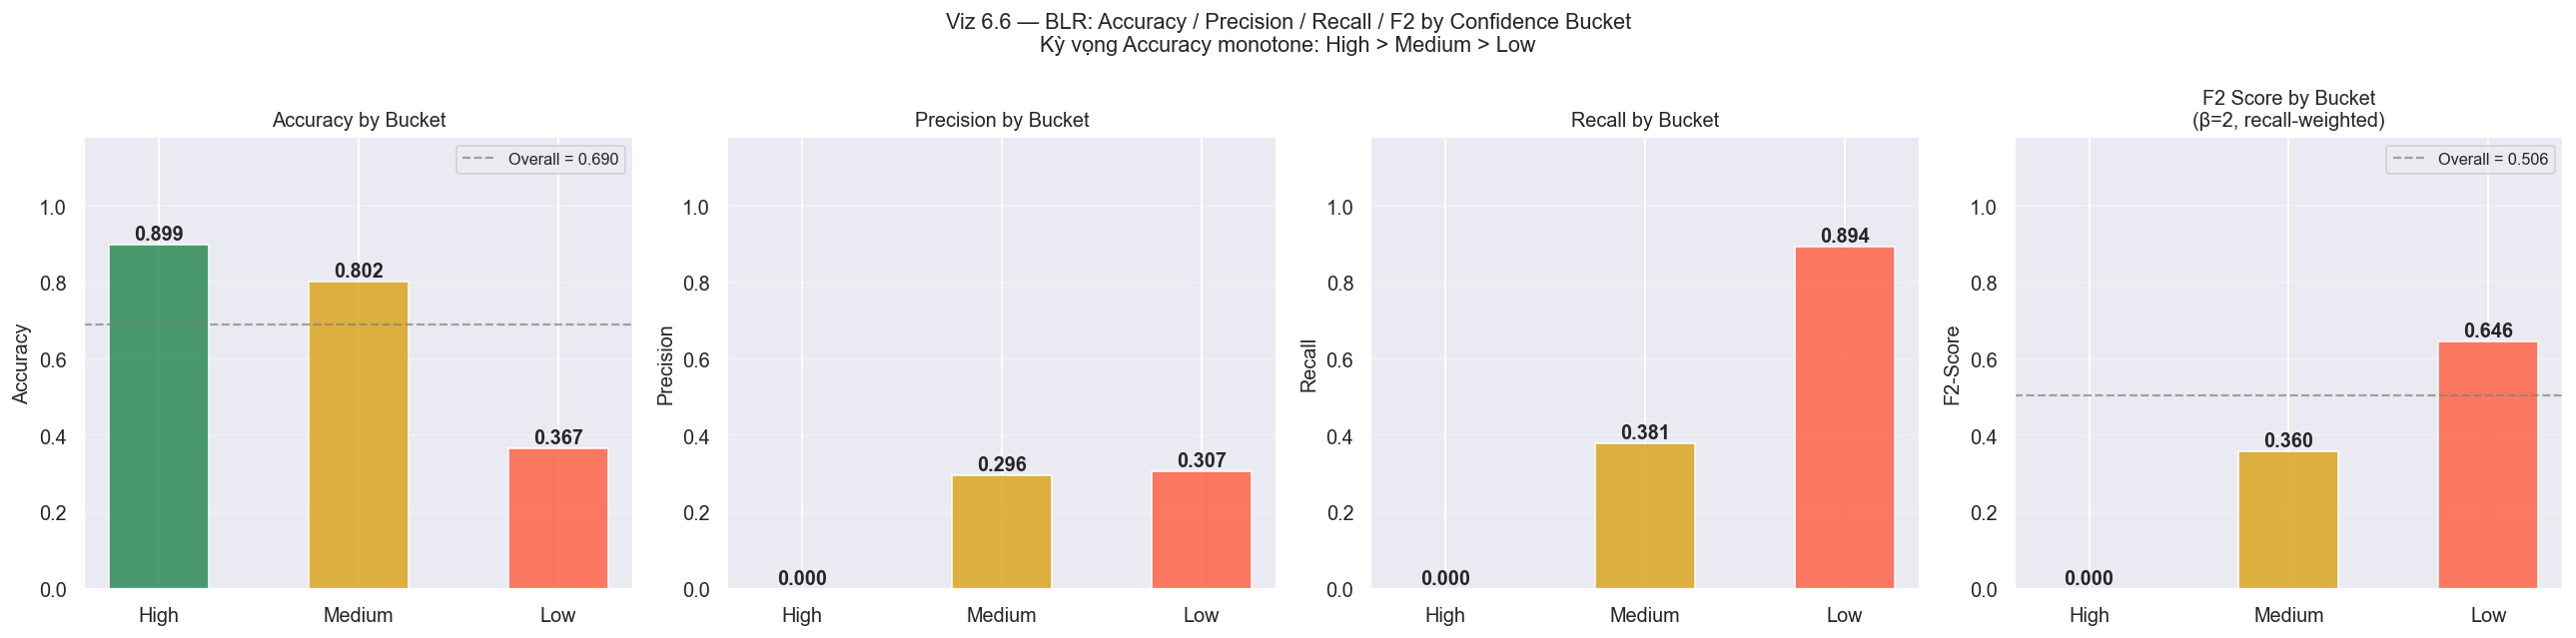

Saved → ../reports/figures/nb6/viz66_bucket_performance.png


In [14]:
# ── Viz 6.6: Accuracy / Precision / Recall / F2 by Bucket ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Viz 6.6 — BLR: Accuracy / Precision / Recall / F2 by Confidence Bucket\n'
             'Kỳ vọng Accuracy monotone: High > Medium > Low', fontsize=12)

bucket_order  = ['High', 'Medium', 'Low']
bucket_colors = ['seagreen', 'goldenrod', 'tomato']

def bar_bucket(ax, metric_key, title, ylabel, overall_val=None):
    vals = [bucket_stats[b][metric_key] for b in bucket_order]
    bars = ax.bar(bucket_order, vals, color=bucket_colors, alpha=0.85, edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.012,
                f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')
    if overall_val is not None:
        ax.axhline(overall_val, color='gray', ls='--', lw=1.2, alpha=0.7,
                   label=f'Overall = {overall_val:.3f}')
        ax.legend(fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.18)
    ax.grid(alpha=0.3, axis='y')

overall_acc = accuracy_score(y_true_blr, y_pred_blr)
overall_f2  = fbeta_score(y_true_blr, y_pred_blr, beta=2, zero_division=0)

bar_bucket(axes[0], 'Accuracy',  'Accuracy by Bucket',  'Accuracy',  overall_acc)
bar_bucket(axes[1], 'Precision', 'Precision by Bucket', 'Precision')
bar_bucket(axes[2], 'Recall',    'Recall by Bucket',    'Recall')
bar_bucket(axes[3], 'F2',        'F2 Score by Bucket\n(β=2, recall-weighted)', 'F2-Score', overall_f2)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz66_bucket_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz66_bucket_performance.png')

## 10. Section 6.7 — Posterior Predictive Distribution (3 observations đại diện)

Trực quan hóa $p(\pi \mid x^*, \mathcal{D})$ cho 3 điểm: confident-correct, uncertain, confident-wrong.

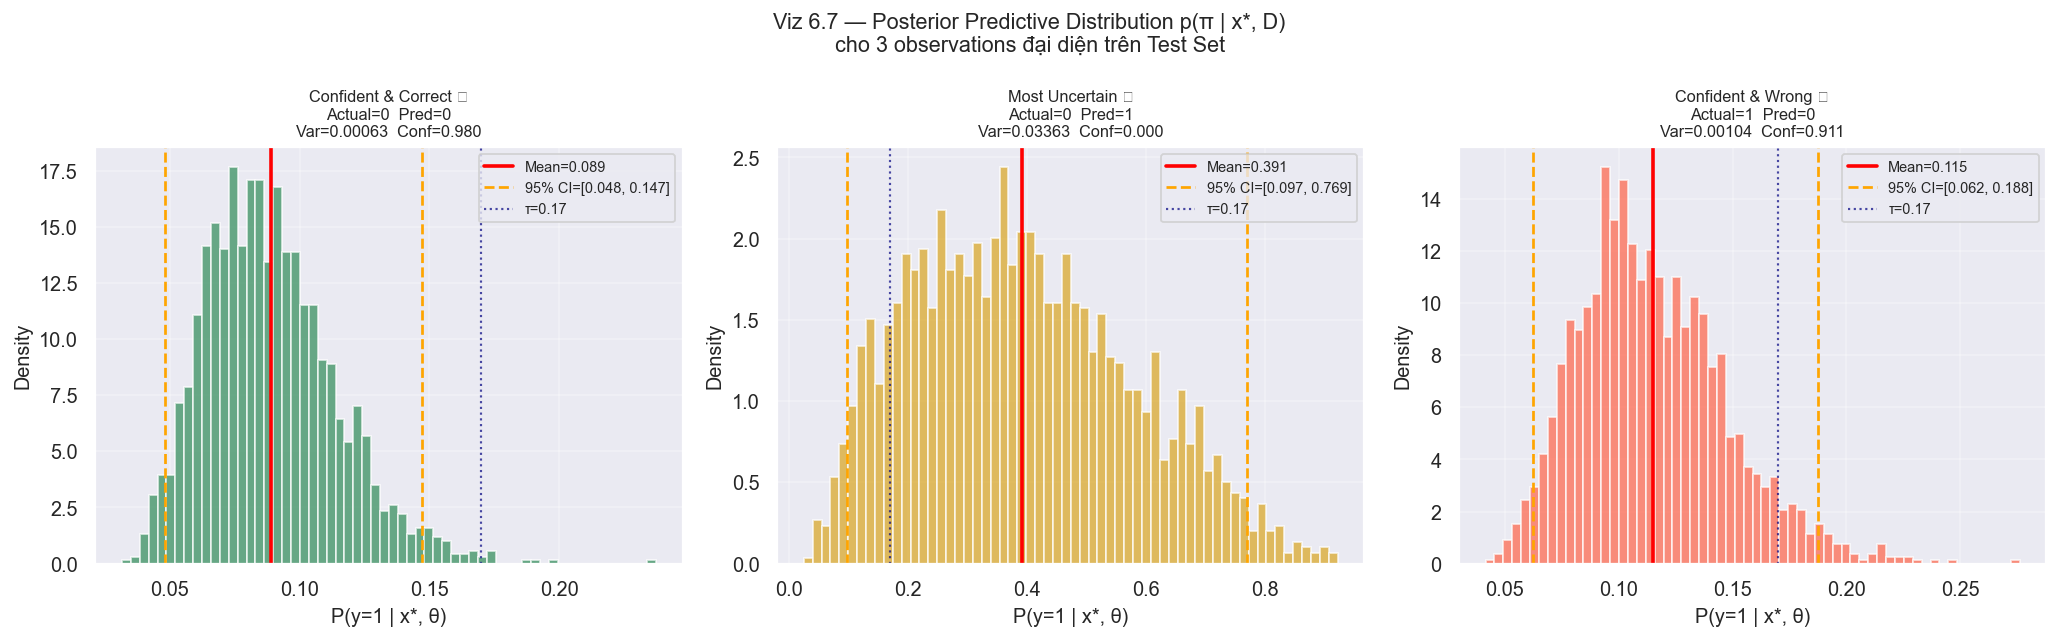

Saved → ../reports/figures/nb6/viz67_predictive_distributions.png


In [15]:
correct_mask = (y_pred_blr == y_true_blr)
wrong_mask   = ~correct_mask

cand_cc = np.where(correct_mask & (confidence_blr >= np.percentile(confidence_blr[correct_mask], 90)))[0]
idx_confident_correct = cand_cc[0] if len(cand_cc) > 0 else np.argmax(confidence_blr * correct_mask)

idx_uncertain = int(np.argmax(pred_var_blr))

cand_cw = np.where(wrong_mask & (confidence_blr >= np.percentile(confidence_blr[wrong_mask], 80)))[0]
idx_confident_wrong = cand_cw[0] if len(cand_cw) > 0 else np.argmax(confidence_blr * wrong_mask)

cases = [
    (idx_confident_correct, 'Confident & Correct', 'seagreen'),
    (idx_uncertain,         'Most Uncertain',       'goldenrod'),
    (idx_confident_wrong,   'Confident & Wrong',    'tomato'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Viz 6.7 — Posterior Predictive Distribution p(π | x*, D)\n'
             'cho 3 observations đại diện trên Test Set', fontsize=12)

for ax, (idx, case_name, color) in zip(axes, cases):
    samples_i = probs_test[:, idx]
    ax.hist(samples_i, bins=60, density=True, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(pred_mean_blr[idx], color='red',    lw=2,   label=f'Mean={pred_mean_blr[idx]:.3f}')
    ax.axvline(ci_lower_blr[idx],  color='orange', lw=1.5, ls='--',
               label=f'95% CI=[{ci_lower_blr[idx]:.3f}, {ci_upper_blr[idx]:.3f}]')
    ax.axvline(ci_upper_blr[idx],  color='orange', lw=1.5, ls='--')
    ax.axvline(BLR_THRESHOLD, color='navy', lw=1.2, ls=':',
               alpha=0.7, label=f'τ={BLR_THRESHOLD}')
    correct_str = '✓' if y_pred_blr[idx] == y_true_blr[idx] else '✗'
    ax.set_title(
        f'{case_name} {correct_str}\n'
        f'Actual={y_true_blr[idx]}  Pred={y_pred_blr[idx]}\n'
        f'Var={pred_var_blr[idx]:.5f}  Conf={confidence_blr[idx]:.3f}',
        fontsize=9
    )
    ax.set_xlabel('P(y=1 | x*, θ)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/viz67_predictive_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIGURES_DIR}/viz67_predictive_distributions.png')

## 11. Lưu kết quả

In [16]:
blr_test_preds = pd.DataFrame({
    'Actual'             : y_true_blr,
    'Prediction'         : y_pred_blr,
    'Predictive_Mean'    : pred_mean_blr,
    'Predictive_Variance': pred_var_blr,
    'CI_Lower'           : ci_lower_blr,
    'CI_Upper'           : ci_upper_blr,
    'CI_Width'           : ci_width_blr,
    'Confidence'         : confidence_blr,
    'Confidence_Bucket'  : conf_bucket,
}, index=pd.to_datetime(test_dates))
blr_test_preds.index.name = 'Date'
blr_test_preds.to_csv(f'{PROCESSED_DIR}/blr_test_predictions.csv')
print(f'✓ Saved → {PROCESSED_DIR}/blr_test_predictions.csv')

comparison_output = {
    'test_period': {
        'start': str(pd.to_datetime(test_dates).min().date()),
        'end'  : str(pd.to_datetime(test_dates).max().date()),
        'n'    : int(len(y_test))
    },
    'note'               : 'Fair head-to-head: LR and BLR evaluated on the same test set. Primary metric: F2 (beta=2).',
    'logistic_regression': {k: round(float(v), 4) for k,v in metrics_lr.items()  if k != 'Model'},
    'bayesian_lr'        : {k: round(float(v), 4) for k,v in metrics_blr.items() if k != 'Model'},
    'bayesian_lr_config' : {
        'threshold'       : BLR_THRESHOLD,
        'threshold_metric': 'F2 (beta=2)',
        'mc_samples'      : M,
        'posterior_from'  : 'NB4 posterior_final.pkl',
        'confidence_normalization': 'robust quantile (p2.5–p97.5)'
    },
    'performance_by_confidence_bucket': {
        b: {
            'n'              : int(bucket_stats[b]['N']),
            'accuracy'       : round(float(bucket_stats[b]['Accuracy']),  4),
            'precision'      : round(float(bucket_stats[b]['Precision']), 4),
            'recall'         : round(float(bucket_stats[b]['Recall']),    4),
            'f2'             : round(float(bucket_stats[b]['F2']),        4),
            'mean_variance'  : round(float(bucket_stats[b]['Mean Variance']),   6),
            'mean_confidence': round(float(bucket_stats[b]['Mean Confidence']), 4),
        }
        for b in ['High', 'Medium', 'Low']
    },
    'monotonicity_acc': bool(mono_acc),
}

with open(f'{RESULTS_DIR}/comparison_metrics.json', 'w') as f:
    json.dump(comparison_output, f, indent=2)
print(f'✓ Saved → {RESULTS_DIR}/comparison_metrics.json')

print()
print('=' * 60)
print('  SUMMARY — Head-to-Head (same test set)')
print('=' * 60)
print(metrics_df[['Accuracy','Precision','Recall','F2-Score','ROC-AUC','Brier Score']].round(4).to_string())
print()
print(f'Monotonicity Accuracy (High>Med>Low): {"✓ HOLD" if mono_acc else "✗ FAIL"}')
print(f'  High={acc_high:.4f}  Medium={acc_med:.4f}  Low={acc_low:.4f}')

✓ Saved → ../data/processed/blr_test_predictions.csv
✓ Saved → ../results/comparison/comparison_metrics.json

  SUMMARY — Head-to-Head (same test set)
                     Accuracy  Precision  Recall  F2-Score  ROC-AUC  Brier Score
Model                                                                           
Logistic Regression    0.6297     0.2791  0.7317    0.5525    0.687       0.1982
Bayesian LR            0.6904     0.3012  0.6098    0.5061    0.675       0.1361

Monotonicity Accuracy (High>Med>Low): ✓ HOLD
  High=0.8987  Medium=0.8025  Low=0.3671
